<a href="https://colab.research.google.com/github/Brajaraj-Pal/SoC-RL/blob/main/Week%203/01-mdp-formulation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 01 — MDP Formulation
**Week 3 | RL Fundamentals**

A **Markov Decision Process** (MDP) is defined by the 5-tuple:

$$M = (\mathcal{S},\; \mathcal{A},\; \mathcal{R},\; \mathcal{T},\; \gamma)$$

| Symbol | Meaning |
|---|---|
| S | State space |
| A | Action space |
| R(s,a,s') | Reward function |
| T(s,a,s') | Transition function P(s'|s,a) |
| γ ∈ [0,1) | Discount factor |

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
np.random.seed(0)

## 1. Constructing a Tiny MDP by Hand
A recycling robot (from Sutton & Barto, Example 3.3):  
- **States**: {high battery, low battery}  
- **Actions**: {search, wait, recharge}  
- **Goal**: maximise cans collected

In [2]:
# States
S = ['high', 'low']
s_idx = {s: i for i, s in enumerate(S)}

# Actions (not all available in every state but we'll handle that via masks)
A = ['search', 'wait', 'recharge']
a_idx = {a: i for i, a in enumerate(A)}

# Transition tensor: T[s, a, s'] = P(s'|s,a)
# and Reward matrix:  R[s, a] = expected reward
alpha = 0.9   # P(stay high | high, search)
beta  = 0.4   # P(stay low  | low,  search)
r_search_high = 4.0
r_search_low  = 2.0
r_wait        = 1.0

T = np.zeros((2, 3, 2))   # (states, actions, next_states)
R = np.full((2, 3), -np.inf)  # -inf for illegal actions

# From HIGH
T[0, 0, 0] = alpha;    T[0, 0, 1] = 1 - alpha;  R[0, 0] = r_search_high  # search
T[0, 1, 0] = 1.0;                                R[0, 1] = r_wait         # wait
# recharge not available from high

# From LOW
T[1, 0, 0] = 1-beta;   T[1, 0, 1] = beta;        R[1, 0] = r_search_low   # search
T[1, 1, 1] = 1.0;                                 R[1, 1] = r_wait         # wait
T[1, 2, 0] = 1.0;                                 R[1, 2] = 0.0            # recharge

print("Transition tensor shape:", T.shape, "  (states × actions × next_states)")
print("\nReward matrix R[s,a]:")
for i, s in enumerate(S):
    for j, a in enumerate(A):
        r = R[i, j]
        print(f"  R[{s},{a}] = {r if r != -np.inf else 'N/A'}")

Transition tensor shape: (2, 3, 2)   (states × actions × next_states)

Reward matrix R[s,a]:
  R[high,search] = 4.0
  R[high,wait] = 1.0
  R[high,recharge] = N/A
  R[low,search] = 2.0
  R[low,wait] = 1.0
  R[low,recharge] = 0.0


## 2. Simulate One Episode Under a Random Policy

In [3]:
def valid_actions(s):
    if s == 0:  return [0, 1]        # high: search, wait
    else:       return [0, 1, 2]     # low:  search, wait, recharge

def step(s, a):
    next_s = np.random.choice(2, p=T[s, a])
    r = R[s, a]
    return next_s, r

def simulate_episode(start=0, n_steps=20, gamma=0.95):
    s = start
    trajectory = []
    for t in range(n_steps):
        a = np.random.choice(valid_actions(s))
        next_s, r = step(s, a)
        trajectory.append({'t': t, 'state': S[s], 'action': A[a], 'reward': r, 'next': S[next_s]})
        s = next_s
    return trajectory

traj = simulate_episode()
print(f"{'t':>3}  {'State':<8} {'Action':<10} {'Reward':>7}  {'Next':>8}")
print("-" * 45)
for step_ in traj[:10]:
    print(f"{step_['t']:>3}  {step_['state']:<8} {step_['action']:<10} {step_['reward']:>7.1f}  {step_['next']:>8}")

  t  State    Action      Reward      Next
---------------------------------------------
  0  high     search         4.0      high
  1  high     search         4.0      high
  2  high     wait           1.0      high
  3  high     wait           1.0      high
  4  high     search         4.0      high
  5  high     search         4.0       low
  6  low      recharge       0.0      high
  7  high     wait           1.0      high
  8  high     search         4.0      high
  9  high     wait           1.0      high


## 3. Real-World MDP Formulations
Practice framing problems as MDPs before coding them.

In [4]:
problems = {
    "Taxi Driver": {
        "States":   "(row, col, passenger_loc, destination) — 500 states",
        "Actions":  "N, S, E, W, Pickup, Dropoff",
        "Reward":   "-1 per step, +20 for delivery, -10 illegal pickup/dropoff",
        "Terminal": "After successful dropoff",
        "gamma":    0.99,
    },
    "CartPole": {
        "States":   "(cart_pos, cart_vel, pole_angle, pole_vel) — continuous R^4",
        "Actions":  "Push left (0) or Push right (1)",
        "Reward":   "+1 for every timestep the pole stays upright",
        "Terminal": "Pole falls >15° or cart moves >2.4 from centre",
        "gamma":    1.0,
    },
    "Trading Agent": {
        "States":   "(price_history, holdings, cash, technical_indicators)",
        "Actions":  "Buy / Sell / Hold (continuous or discrete)",
        "Reward":   "Change in portfolio value or Sharpe ratio",
        "Terminal": "End of trading day / time horizon reached",
        "gamma":    0.99,
    },
}

for name, mdp in problems.items():
    print(f"\n=== {name} ===")
    for k, v in mdp.items():
        print(f"  {k:<10}: {v}")


=== Taxi Driver ===
  States    : (row, col, passenger_loc, destination) — 500 states
  Actions   : N, S, E, W, Pickup, Dropoff
  Reward    : -1 per step, +20 for delivery, -10 illegal pickup/dropoff
  Terminal  : After successful dropoff
  gamma     : 0.99

=== CartPole ===
  States    : (cart_pos, cart_vel, pole_angle, pole_vel) — continuous R^4
  Actions   : Push left (0) or Push right (1)
  Reward    : +1 for every timestep the pole stays upright
  Terminal  : Pole falls >15° or cart moves >2.4 from centre
  gamma     : 1.0

=== Trading Agent ===
  States    : (price_history, holdings, cash, technical_indicators)
  Actions   : Buy / Sell / Hold (continuous or discrete)
  Reward    : Change in portfolio value or Sharpe ratio
  Terminal  : End of trading day / time horizon reached
  gamma     : 0.99


## ✅ Exercises
1. Formalise a **Frozen Lake 4×4** as an MDP. How many states? How many actions? What are the terminal states?
2. Pick a board game you know (noughts & crosses, connect 4). Define S, A, R, and T for it.
3. **Challenge**: simulate 1000 episodes of the recycling robot under the policy 'always search'. Plot the distribution of total undiscounted reward per episode.

### Exercise 1: Frozen Lake 4x4 MDP Formulation
* **States ($S$):** 16 states total (a 4x4 grid). Each state is a specific (row, col) coordinate, numbered 0 to 15.
* **Actions ($A$):** 4 discrete actions: 0=Left, 1=Down, 2=Right, 3=Up.
* **Rewards ($R$):** +1 for reaching the Goal state. 0 for all other transitions.
* **Transition ($T$):** If the ice is slippery, moving 'Up' might actually result in moving Left or Right with a 33% chance each. If non-slippery, P(s'|s,a) = 1.0 for the intended direction.
* **Terminal States:** Any 'Hole' state or the 'Goal' state.

### Exercise 2: Board Game MDP Formulation (Tic-Tac-Toe / Noughts & Crosses)
* **States ($S$):** All possible configurations of the 3x3 board (X, O, or Empty). There are technically $3^9 = 19,683$ possible states (though many are unreachable or symmetrical).
* **Actions ($A$):** Placing a mark in one of the remaining empty squares (between 1 and 9 possible actions depending on the state).
* **Rewards ($R$):** +1 for winning, -1 for losing, 0 for a draw, and 0 for all intermediate moves.
* **Transition ($T$):** Deterministic for the agent's turn (P=1.0), but from the perspective of a single agent, the transition to the *next* state depends on the opponent's strategy.

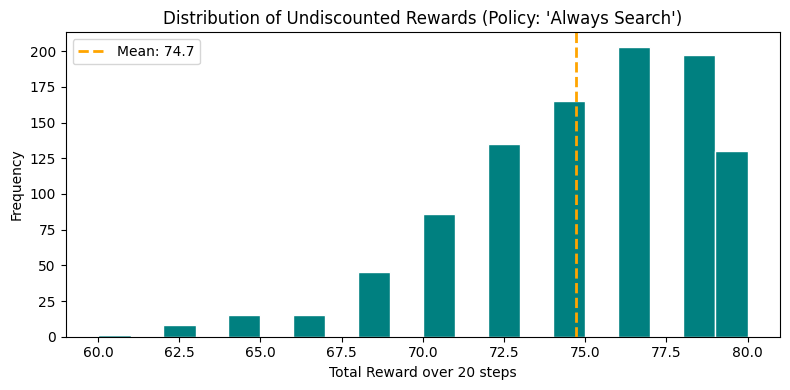

In [5]:
# Exercise 3: Challenge - Simulate 1000 Episodes of 'Always Search' Policy
n_episodes = 1000
n_steps = 20
total_rewards = []

for _ in range(n_episodes):
    # The agent always starts in 'high' battery state (state 0)
    s = 0
    episode_reward = 0

    for t in range(n_steps):
        # Policy: Always search (Action 0)
        a = 0

        # Take a step using the T and R matrices defined earlier
        next_s = np.random.choice(2, p=T[s, a])
        r = R[s, a]

        episode_reward += r
        s = next_s # Update state

    total_rewards.append(episode_reward)

# Plot the distribution of rewards
plt.figure(figsize=(8, 4))
plt.hist(total_rewards, bins=20, color='teal', edgecolor='white')
plt.title("Distribution of Undiscounted Rewards (Policy: 'Always Search')")
plt.xlabel("Total Reward over 20 steps")
plt.ylabel("Frequency")
plt.axvline(np.mean(total_rewards), color='orange', linestyle='dashed', linewidth=2, label=f'Mean: {np.mean(total_rewards):.1f}')
plt.legend()
plt.tight_layout()
plt.show()